# Template Matching
OpenCV has a `matchTemplate()` function to perform template matching.


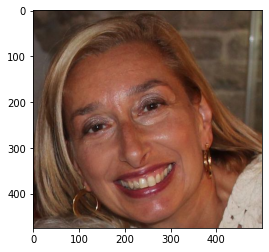

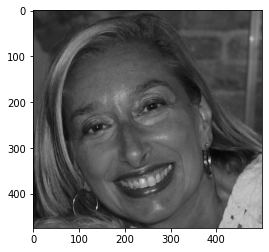

In [7]:
#Import the OpenCV and NumPy libraries.
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Loads the bigger image in which the template image needs to be searched for
# and convert it to grayscale.
image = cv2.imread('gio.jpg', cv2.IMREAD_COLOR)
#image=cv2.imread('faces.jpeg', cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# cv2.imshow(image)
# cv2.imshow() is disabled in Colab, because it causes Jupyter sessions to crash;
plt.imshow(image)
plt.show()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap='gray')
plt.show()

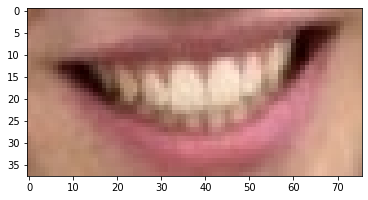

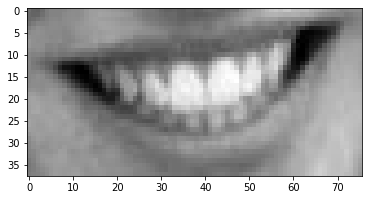

height= 38 width= 76


In [8]:
# Load the image of the object that needs to be searched for
# and convert it to grayscale.
temp = cv2.imread('mouth-template.jpeg', cv2.IMREAD_COLOR)
temp = cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)
# cv2.imshow(image)
# cv2.imshow() is disabled in Colab, because it causes Jupyter sessions to crash;
plt.imshow(temp)
plt.show()

graytemplate = cv2.cvtColor(temp, cv2.COLOR_BGR2GRAY)
plt.imshow(graytemplate,cmap='gray')
plt.show()
print('height=',temp.shape[0],'width=',temp.shape[1])

The cv2.matchTemplate() returns a correlation map, essentially a grayscale image. Each pixel in this image denotes the extent to which its neighborhood matches with the template. The minMaxLoc function returns the max and min intensity values as an array that includes the location of these intensities. MaxVal is the location with the highest intensity in the image. This is
returned by matchTemplate() and corresponds to the best matching input
image with regard to the defined template.

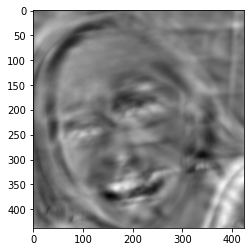

Location of maximum value: (424, 338)


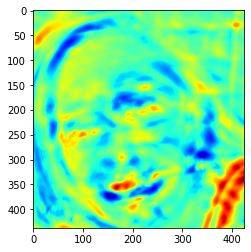

In [9]:
result = cv2.matchTemplate(gray, graytemplate, cv2.TM_CCOEFF)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

plt.imshow(result,cmap='gray')
plt.show()
print('Location of maximum value:', max_loc)


plt.imshow(result,cmap='jet')
plt.show()


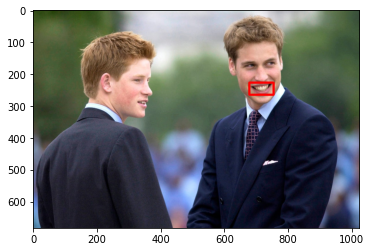

In [4]:
#Create Bounding Box near maximum value
# Copy the image
img_copy = image.copy() 
top_left = max_loc
bottom_right = (top_left[0]+temp.shape[1], top_left[1]+temp.shape[0])
cv2.rectangle(img_copy, top_left, bottom_right, color=(255, 0, 0), thickness=5)
plt.imshow(img_copy)
plt.show()

# Challenges with Template Matching
Template matching can find the template in the image but it may also detect other parts that are not equal to the template! If the image is rotated, scaled, modified for colors or
brightness, or transformed, it is even difficult to match or detect an input template in the image.